In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path
from IPython.display import display

ROOT = Path("../inference/clipseg_cloudsen12plus_prompt_variants").expanduser().resolve()

def get_agg_row(df: pd.DataFrame, csv_path: Path) -> pd.Series:
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    return agg.iloc[0]

iou_csvs = sorted(ROOT.glob("V*_iou.csv"))
if not iou_csvs:
    raise FileNotFoundError(f"No V*_iou.csv files found in: {ROOT}")

rows = []
for p in iou_csvs:
    tag = p.stem.replace("_iou", "")
    df = pd.read_csv(p)
    agg = get_agg_row(df, p)

    out = {"variant": tag}

    iou_cols = [c for c in df.columns if c.startswith("iou_")]
    if "miou" in df.columns:
        out["miou"] = float(agg["miou"])
    elif iou_cols:
        out["miou"] = float(pd.to_numeric(agg[iou_cols], errors="coerce").mean())
    else:
        out["miou"] = np.nan

    for c in iou_cols:
        out[c] = float(pd.to_numeric(agg[c], errors="coerce"))

    rows.append(out)

variant_df = pd.DataFrame(rows)

variant_df["vnum"] = variant_df["variant"].str.extract(r"V(\d+)", expand=False).astype(int)
variant_df = variant_df.sort_values("vnum").drop(columns=["vnum"]).reset_index(drop=True)

display(variant_df)

,variant,miou,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,V1,0.222039,0.361088,0.308159,0.083555,0.135353
1,V2,0.196456,0.291248,0.345006,0.022516,0.127055
2,V3,0.165606,0.223484,0.289099,0.090741,0.059100
3,V4,0.164304,0.347268,0.138881,0.091394,0.079675
4,V5,0.187621,0.277354,0.293561,0.079286,0.100283
5,V6,0.165336,0.268412,0.254362,0.026659,0.111909
6,V7,0.067676,0.057729,0.068061,0.078974,0.065940
7,V8,0.216400,0.502066,0.168840,0.072285,0.122407
8,V9,0.165080,0.402239,0.102546,0.096379,0.059158
9,V10,0.107816,0.158710,0.144901,0.078622,0.049031


In [4]:
from pathlib import Path
import pandas as pd

ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv").expanduser().resolve()
print("ZS_MIOU_CSV:", ZS_MIOU_CSV, "exists:", ZS_MIOU_CSV.exists())

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = get_agg_row(zs_df, ZS_MIOU_CSV)

zs_vals = {
    "miou": float(zs_agg["miou"]),
    "iou_clear": float(zs_agg["iou_clear"]),
    "iou_thick_cloud": float(zs_agg["iou_thick_cloud"]),
    "iou_thin_cloud": float(zs_agg["iou_thin_cloud"]),
    "iou_cloud_shadow": float(zs_agg["iou_cloud_shadow"]),
}

zs_vals

ZS_MIOU_CSV: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv exists: True


{'miou': 0.2550400406013244,
 'iou_clear': 0.520532380887666,
 'iou_thick_cloud': 0.277302215426787,
 'iou_thin_cloud': 0.0898395431914562,
 'iou_cloud_shadow': 0.1324860228993884}

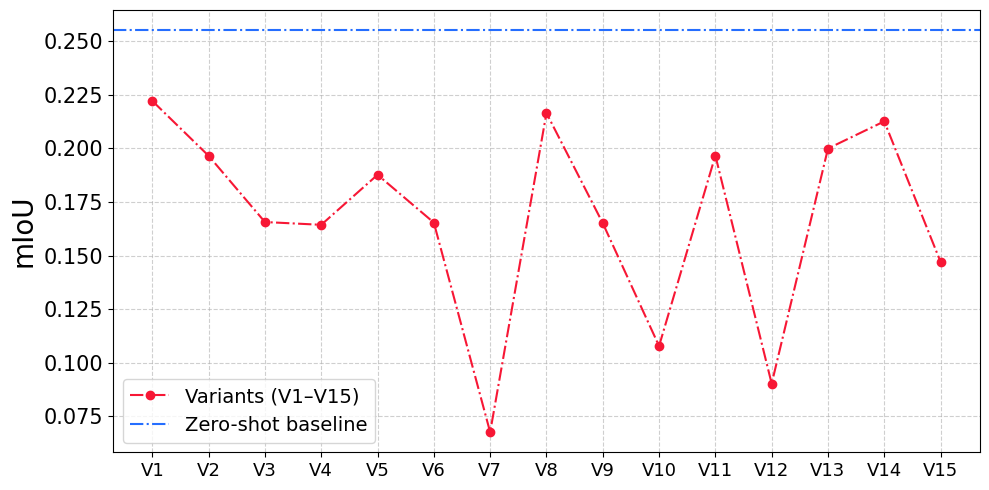

In [24]:
def plot_variants_vs_zs(metric: str, ylabel: str):
    x_labels = variant_df["variant"].tolist()
    y = variant_df[metric].astype(float).tolist()
    z = zs_vals[metric]

    plt.figure(figsize=(10, 5))

    plt.plot(
        range(len(x_labels)),
        y,
        marker="o",
        linestyle="-.",
        color="#f71735",
        label="Variants (V1–V15)"
    )

    plt.axhline(
        z,
        linestyle="-.",
        color="#256eff",
        label="Zero-shot baseline"
    )

    plt.xticks(range(len(x_labels)), x_labels, fontsize=13, rotation=0)
    plt.yticks(fontsize=15)
    plt.ylabel(ylabel, fontsize=20)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

plot_variants_vs_zs("miou", "mIoU")